In [103]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy
from scipy.stats import spearmanr
from scipy.stats import kendalltau
from scipy.stats import pearsonr
from scipy.stats import fisher_exact
from scipy.stats import pointbiserialr
from scipy.stats import ttest_ind

In [104]:
df = pd.read_csv("./cleaned_data.csv", sep=",")
df.head()

,calls_count_in_weekdays,calls_count_out_weekdays,calls_count_in_weekends,calls_count_out_weekends,DATA_VOLUME_WEEKDAYS,DATA_VOLUME_WEEKENDS,sim_count,AVG_ARPU,ROUM,phone_value,...,Brand_Samsung,Brand_Xiaomi,SCORING_Numeric,Is_Big_City_WORK,City_Population_Proxy_WORK,Raion_Density_WORK,Oblast_Density_HOME,Oblast_Density_WORK,Tech_Refresh_Rate,Affluence_Index
0,10.87,17.74,7.00,11.13,154.837,181.143,2.0,260.739450,0.0,3.0,...,1,0,3.0,1,698,702,936,945,0.629723,521.478900
1,0.91,0.48,0.25,0.75,53.639,49.009,2.0,52.635025,0.0,3.0,...,0,0,1.0,1,698,702,936,945,0.062292,105.270050
2,7.39,11.00,5.00,8.38,0.000,0.000,2.0,41.816525,0.0,4.0,...,0,0,1.0,0,1,94,1435,1428,0.288573,41.816525
3,0.43,0.70,2.25,0.00,0.000,0.000,2.0,39.863417,0.0,3.0,...,0,0,1.0,0,31,34,709,697,0.175305,79.726833
4,5.39,4.22,2.75,3.13,47.659,23.868,2.0,55.291350,0.0,3.0,...,0,0,1.0,1,1325,1325,1801,1813,0.087362,110.582700


In [105]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16794 entries, 0 to 16793
Data columns (total 78 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   calls_count_in_weekdays      16794 non-null  float64
 1   calls_count_out_weekdays     16794 non-null  float64
 2   calls_count_in_weekends      16794 non-null  float64
 3   calls_count_out_weekends     16794 non-null  float64
 4   DATA_VOLUME_WEEKDAYS         16794 non-null  float64
 5   DATA_VOLUME_WEEKENDS         16794 non-null  float64
 6   sim_count                    16794 non-null  float64
 7   AVG_ARPU                     16794 non-null  float64
 8   ROUM                         16794 non-null  float64
 9   phone_value                  16794 non-null  float64
 10  car                          16794 non-null  int64  
 11  gender                       16794 non-null  int64  
 12  lifetime                     16794 non-null  float64
 13  how_long_same_mo

In [106]:
df['target'].value_counts()

target
4    4984
5    4810
3    3471
6    2168
2     936
1     425
Name: count, dtype: int64

<center><h1>КЛАСТЕРИЗАЦИЯ<h1><center>

In [107]:
from sklearn.preprocessing import StandardScaler

X_scaled = StandardScaler().fit_transform(df)
print(X_scaled)

[[ 0.93288019  1.99931114  0.85142789 ... -0.28795108  2.65239679
   1.0778377 ]
 [-0.76396894 -0.82185147 -0.68483921 ... -0.28795108 -0.6382048
  -0.2497851 ]
 [ 0.34000519  0.89765204  0.39623764 ...  0.24752357  0.67402251
  -0.45218913]
 ...
 [-0.88152174 -0.736857   -0.74173799 ... -0.28795108 -0.57717958
  -0.1015246 ]
 [-0.06035579  0.14414338 -0.22964896 ... -1.04404572 -0.84250083
  -0.38941491]
 [ 1.86648794  4.31541045 -0.42765672 ... -0.61832675 -0.05862339
   0.19436833]]


In [108]:
from sklearn.metrics import pairwise_distances
pd.DataFrame(pairwise_distances(X_scaled))

,0,1,2,3,4,5,6,7,8,9,...,16784,16785,16786,16787,16788,16789,16790,16791,16792,16793
0,0.000000,13.771050,12.537474,12.544047,12.749862,12.526290,13.155987,13.192182,13.533402,13.110275,...,11.415051,16.962945,12.452041,11.554569,11.260761,13.477768,12.928440,12.724783,12.887762,11.154409
1,13.771050,0.000000,9.489297,8.123969,7.965907,8.931840,9.207637,9.961704,9.470280,9.394214,...,8.084155,13.366248,10.331985,8.808392,9.504629,9.845248,8.532145,10.323185,8.057078,10.226230
2,12.537474,9.489297,0.000000,6.495735,7.358596,5.779921,4.882073,10.453592,5.000118,7.974397,...,7.194612,15.081079,8.349215,7.933947,8.894977,6.560827,8.305734,10.951356,9.444655,8.562970
3,12.544047,8.123969,6.495735,0.000000,7.127623,6.952520,6.206284,10.319855,6.916090,6.202716,...,6.045367,14.524403,6.963424,6.648998,8.580374,6.725545,6.689043,9.596169,8.756619,8.969589
4,12.749862,7.965907,7.358596,7.127623,0.000000,8.492057,7.887367,10.493252,8.323343,8.328656,...,7.765283,14.712761,8.956015,8.172546,6.516096,9.602560,8.453593,8.808520,9.376609,9.185060
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16789,13.477768,9.845248,6.560827,6.725545,9.602560,6.118061,6.122812,10.443495,5.242744,9.342778,...,7.234325,15.291056,9.181473,7.563751,10.612854,0.000000,9.140078,11.377232,10.155507,9.879367
16790,12.928440,8.532145,8.305734,6.689043,8.453593,8.256661,8.489112,8.999146,8.871756,5.894151,...,6.628035,14.140041,8.586846,7.635659,9.080727,9.140078,0.000000,9.329729,9.086406,8.824095
16791,12.724783,10.323185,10.951356,9.596169,8.808520,10.233004,10.854821,11.301064,11.466680,8.221946,...,9.148938,15.668612,10.340185,8.590742,9.106138,11.377232,9.329729,0.000000,10.312691,10.462677
16792,12.887762,8.057078,9.444655,8.756619,9.376609,10.101397,9.220162,10.929663,9.252903,8.887897,...,8.432575,13.901134,10.036511,8.524234,9.290388,10.155507,9.086406,10.312691,0.000000,9.157407


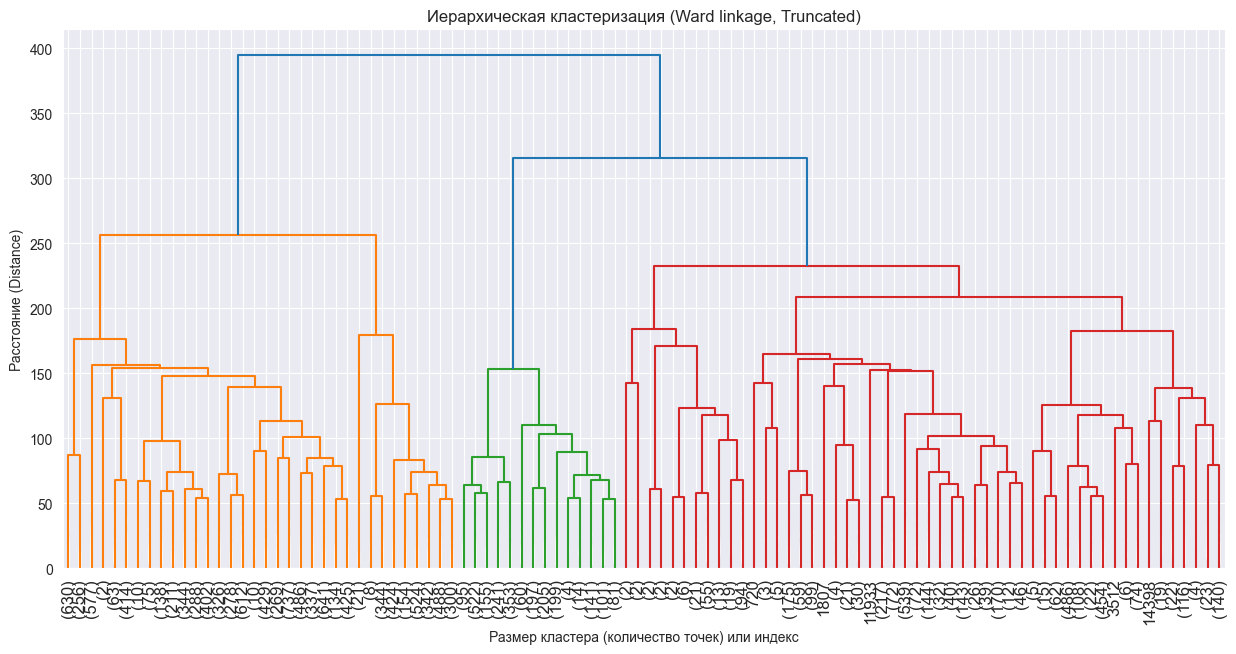

In [109]:
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster

merging = linkage(X_scaled, method='ward')

plt.figure(figsize=(15, 7))

dendrogram(
    merging,
    truncate_mode='lastp',
    p=100,
    leaf_rotation=90,
    leaf_font_size=12,
    show_contracted=True
)

plt.title('Иерархическая кластеризация (Ward linkage, Truncated)')
plt.xlabel('Размер кластера (количество точек) или индекс')
plt.ylabel('Расстояние (Distance)')
plt.show()

In [110]:
clusters = fcluster(merging, 200, criterion='distance')
print(clusters)

[5 5 2 ... 1 5 1]


In [111]:
df_to_claster = df.copy()

df_to_claster['label'] = clusters
print(df_to_claster.sort_values('label')['label'])

25       1
27       1
28       1
30       1
33       1
        ..
6274     6
13280    6
16768    6
16785    6
16761    6
Name: label, Length: 16794, dtype: int32


In [112]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3)
kmeans.fit(X_scaled)
labels = kmeans.predict(X_scaled)

dict(zip(df_to_claster.index, labels))

{0: np.int32(0),
 1: np.int32(1),
 2: np.int32(1),
 3: np.int32(1),
 4: np.int32(2),
 5: np.int32(1),
 6: np.int32(1),
 7: np.int32(0),
 8: np.int32(1),
 9: np.int32(1),
 10: np.int32(1),
 11: np.int32(1),
 12: np.int32(1),
 13: np.int32(1),
 14: np.int32(1),
 15: np.int32(2),
 16: np.int32(1),
 17: np.int32(1),
 18: np.int32(2),
 19: np.int32(2),
 20: np.int32(1),
 21: np.int32(1),
 22: np.int32(1),
 23: np.int32(1),
 24: np.int32(1),
 25: np.int32(2),
 26: np.int32(1),
 27: np.int32(1),
 28: np.int32(1),
 29: np.int32(2),
 30: np.int32(1),
 31: np.int32(1),
 32: np.int32(1),
 33: np.int32(1),
 34: np.int32(0),
 35: np.int32(1),
 36: np.int32(2),
 37: np.int32(0),
 38: np.int32(1),
 39: np.int32(1),
 40: np.int32(2),
 41: np.int32(2),
 42: np.int32(1),
 43: np.int32(1),
 44: np.int32(2),
 45: np.int32(1),
 46: np.int32(1),
 47: np.int32(2),
 48: np.int32(1),
 49: np.int32(1),
 50: np.int32(0),
 51: np.int32(1),
 52: np.int32(1),
 53: np.int32(0),
 54: np.int32(2),
 55: np.int32(2),
 5

In [113]:
pd.Series(labels).value_counts().sort_index()

0     2123
1    10537
2     4134
Name: count, dtype: int64

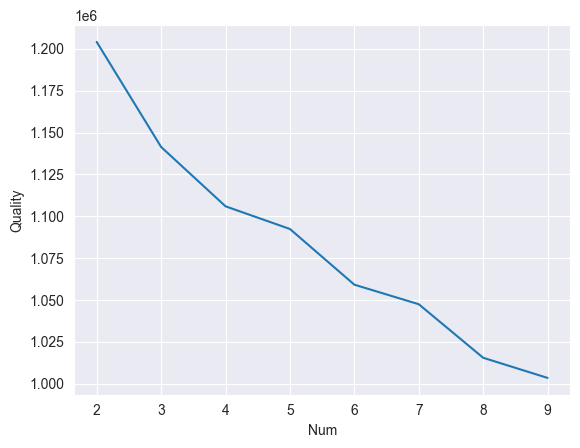

In [114]:
crit = []
for k in range(2, 10):
    kmeans = KMeans(n_clusters=k, random_state=15)
    kmeans.fit(X_scaled)
    crit.append(kmeans.inertia_)

plt.plot(range(2,10), crit)
plt.xlabel('Num')
plt.ylabel('Quality')
plt.show()

In [115]:
kmeans = KMeans(n_clusters=3)
kmeans.fit(X_scaled)
labels = kmeans.predict(X_scaled)

pd.DataFrame(labels, df.index)

,0
0,1
1,0
2,0
3,0
4,2
...,...
16789,0
16790,0
16791,2
16792,0


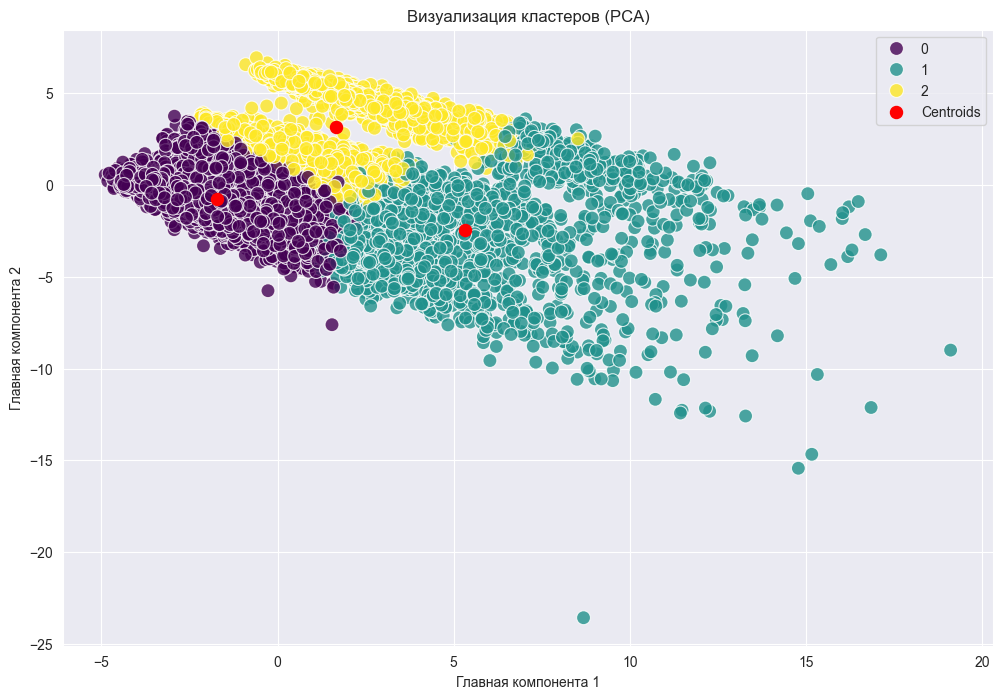

In [116]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

centroids_pca = pca.transform(kmeans.cluster_centers_)

plt.figure(figsize=(12, 8))

sns.scatterplot(
    x=X_pca[:, 0],
    y=X_pca[:, 1],
    hue=labels,
    palette='viridis',
    s=100,
    alpha=0.8
)

plt.scatter(
    centroids_pca[:, 0],
    centroids_pca[:, 1],
    marker='.',
    s=300,
    c='red',
    label='Centroids'
)

plt.title('Визуализация кластеров (PCA)')
plt.xlabel('Главная компонента 1')
plt.ylabel('Главная компонента 2')
plt.legend()
plt.grid(True)
plt.show()

<center><h1>ТРЕНУВАННЯ МОДЕЛЕЙ<h1><center>

<center><h2>RF, MLP, LogReg<h2><center>

In [117]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix

from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.linear_model import LogisticRegression

# results['6_classes']['RF'] = {model, pred, acc}
history = {}

In [118]:
if 'target' in df.columns:
    y_orig = df['target']
    X = df.drop(columns=['target'], errors='ignore')
else:
    raise ValueError("Нет колонки target!")

# 1, 2->Youth(0),
# 3, 4->Adults(1),
# 5, 6->Seniors(2)
group_map = {1: 0, 2: 0,
             3: 1, 4: 1,
             5: 2, 6: 2}
y_grouped = df['target'].map(group_map)

scenarios = [
    ('6_classes', y_orig, ['1', '2', '3', '4', '5', '6']),
    ('3_classes', y_grouped, ['Youth', 'Adults', 'Seniors'])
]

In [119]:
for name, y_target, class_names in scenarios:
    print(f"\n{'='*60}")
    print(f"SCENARIO: {name}")
    print(f"{'='*60}")

    # 1. Разделение выборки (Stratify важно!)
    X_train, X_test, y_train, y_test = train_test_split(
        X, y_target, test_size=0.2, random_state=2025, stratify=y_target
    )

    # For LogRec and MLP
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    history[name] = {
        'y_test': y_test,
        'names': class_names,
        'models': {},
        'preds': {},
        'acc': {}
    }

    # RANDOM FOREST (GridSearch) ---
    print("\nHyperparameter selection for RF...")
    rf_params = {
        'n_estimators': [100, 200],
        'max_depth': [8, 12, None],
        'class_weight': ['balanced']
    }
    grid_rf = GridSearchCV(RandomForestClassifier(random_state=2025), rf_params, cv=3, scoring='accuracy', n_jobs=-1)
    grid_rf.fit(X_train, y_train)

    best_rf = grid_rf.best_estimator_
    y_pred_rf = best_rf.predict(X_test)
    acc_rf = accuracy_score(y_test, y_pred_rf)

    history[name]['models']['RF'] = best_rf
    history[name]['preds']['RF'] = y_pred_rf
    history[name]['acc']['RF'] = acc_rf
    print(f"\tBEST RF Accuracy: {acc_rf:.4f}\n\tBEST PARAMS: {grid_rf.best_params_}")


    # MLP NEURAL NET (RandomizedSearch) ---
    print("\nHyperparameter selection for MLP Neural Network...")
    mlp_params = {
        'hidden_layer_sizes': [(50,), (100,), (50, 50)],
        'alpha': [0.0001, 0.01],
        'learning_rate_init': [0.001, 0.01]
    }
    rand_mlp = RandomizedSearchCV(MLPClassifier(max_iter=500, random_state=42), mlp_params, n_iter=5, cv=3, scoring='accuracy', n_jobs=-1, random_state=2025)
    rand_mlp.fit(X_train_scaled, y_train)

    best_mlp = rand_mlp.best_estimator_
    y_pred_mlp = best_mlp.predict(X_test_scaled)
    acc_mlp = accuracy_score(y_test, y_pred_mlp)

    history[name]['models']['MLP'] = best_mlp
    history[name]['preds']['MLP'] = y_pred_mlp
    history[name]['acc']['MLP'] = acc_mlp
    print(f"\tBEST MLP Accuracy: {acc_mlp:.4f}\n\tBEST PARAMS: {rand_mlp.best_params_}")


    # LOGISTIC REGRESSION (GridSearch) ---
    print("\nHyperparameter selection for Logistic Regression...")
    lr_params = {
        'C': [0.1, 1, 10],
        'class_weight': ['balanced', None]
    }
    grid_lr = GridSearchCV(LogisticRegression(max_iter=1000, random_state=2025), lr_params, cv=3, scoring='accuracy', n_jobs=-1)
    grid_lr.fit(X_train_scaled, y_train)

    best_lr = grid_lr.best_estimator_
    y_pred_lr = best_lr.predict(X_test_scaled)
    acc_lr = accuracy_score(y_test, y_pred_lr)

    history[name]['models']['LogReg'] = best_lr
    history[name]['preds']['LogReg'] = y_pred_lr
    history[name]['acc']['LogReg'] = acc_lr
    print(f"\tBEST LogReg Accuracy: {acc_lr:.4f}\n\tBEST PARAMS: {grid_lr.best_params_}")


SCENARIO: 6_classes

Hyperparameter selection for RF...
	BEST RF Accuracy: 0.4198
	BEST PARAMS: {'class_weight': 'balanced', 'max_depth': None, 'n_estimators': 200}

Hyperparameter selection for MLP Neural Network...
	BEST MLP Accuracy: 0.3834
	BEST PARAMS: {'learning_rate_init': 0.01, 'hidden_layer_sizes': (50,), 'alpha': 0.01}

Hyperparameter selection for Logistic Regression...
	BEST LogReg Accuracy: 0.4085
	BEST PARAMS: {'C': 0.1, 'class_weight': None}

SCENARIO: 3_classes

Hyperparameter selection for RF...
	BEST RF Accuracy: 0.6350
	BEST PARAMS: {'class_weight': 'balanced', 'max_depth': None, 'n_estimators': 200}

Hyperparameter selection for MLP Neural Network...
	BEST MLP Accuracy: 0.5841
	BEST PARAMS: {'learning_rate_init': 0.01, 'hidden_layer_sizes': (50,), 'alpha': 0.01}

Hyperparameter selection for Logistic Regression...
	BEST LogReg Accuracy: 0.6267
	BEST PARAMS: {'C': 0.1, 'class_weight': None}


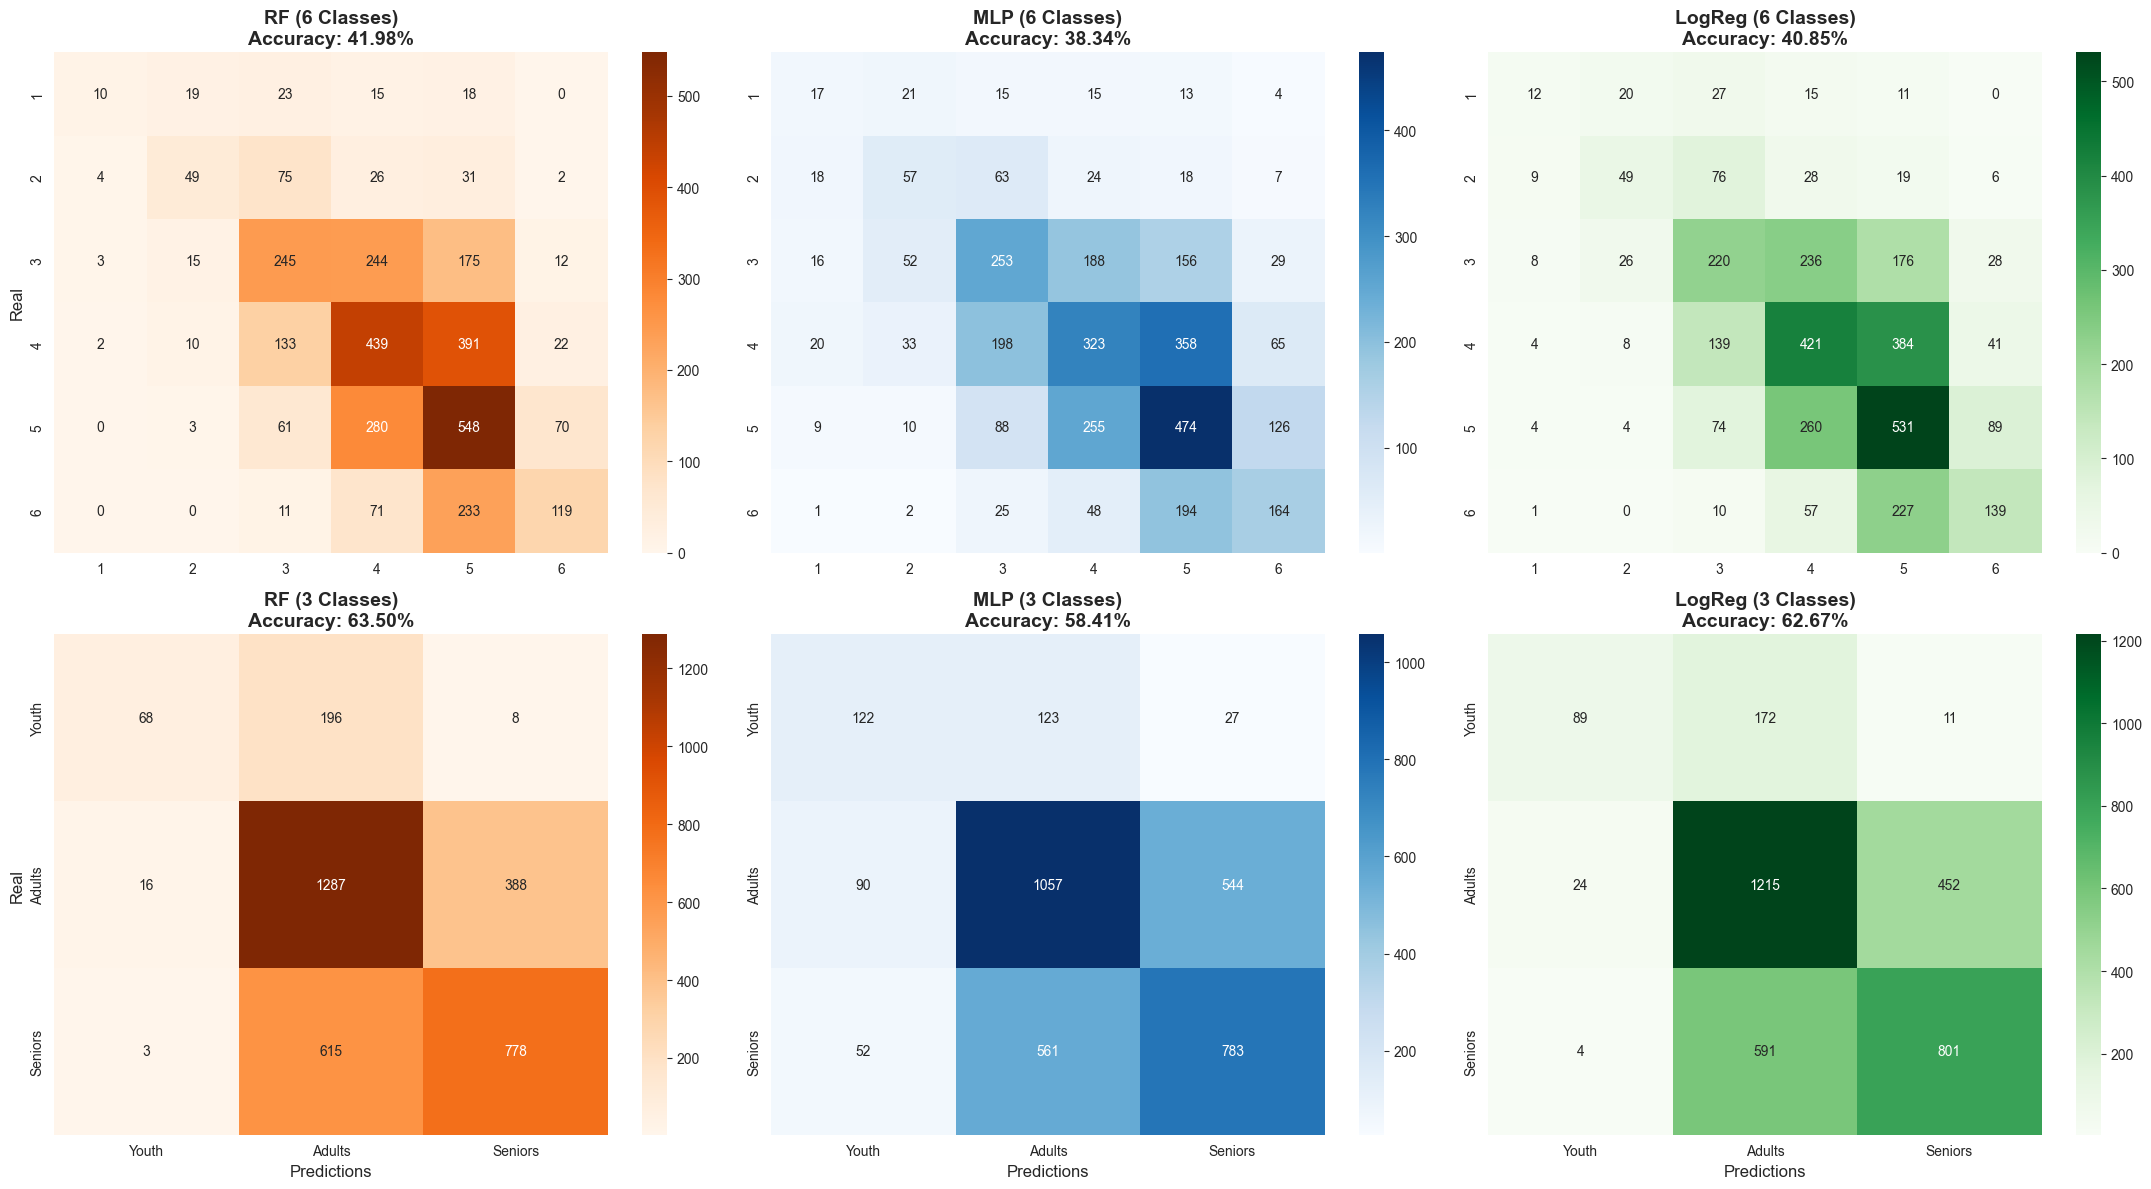

In [120]:
fig, axes = plt.subplots(2, 3, figsize=(22, 12))

for row_idx, (scen_name, _, _) in enumerate(scenarios):
    data = history[scen_name]
    y_true = data['y_test']
    labels = data['names']

    models_list = ['RF', 'MLP', 'LogReg']
    colors = ['Oranges', 'Blues', 'Greens']

    for col_idx, model_name in enumerate(models_list):
        y_pred = data['preds'][model_name]
        acc = data['acc'][model_name]
        ax = axes[row_idx, col_idx]

        cm = confusion_matrix(y_true, y_pred)
        sns.heatmap(cm, annot=True, fmt='d', cmap=colors[col_idx], ax=ax,
                    xticklabels=labels, yticklabels=labels)

        if row_idx == 0:
            ax.set_title(f"{model_name} (6 Classes)\nAccuracy: {acc:.2%}", fontsize=14, fontweight='bold')
        else:
            ax.set_title(f"{model_name} (3 Classes)\nAccuracy: {acc:.2%}", fontsize=14, fontweight='bold')
            ax.set_xlabel('Predictions', fontsize=12)

        if col_idx == 0:
            ax.set_ylabel('Real', fontsize=12)

plt.tight_layout()
plt.show()

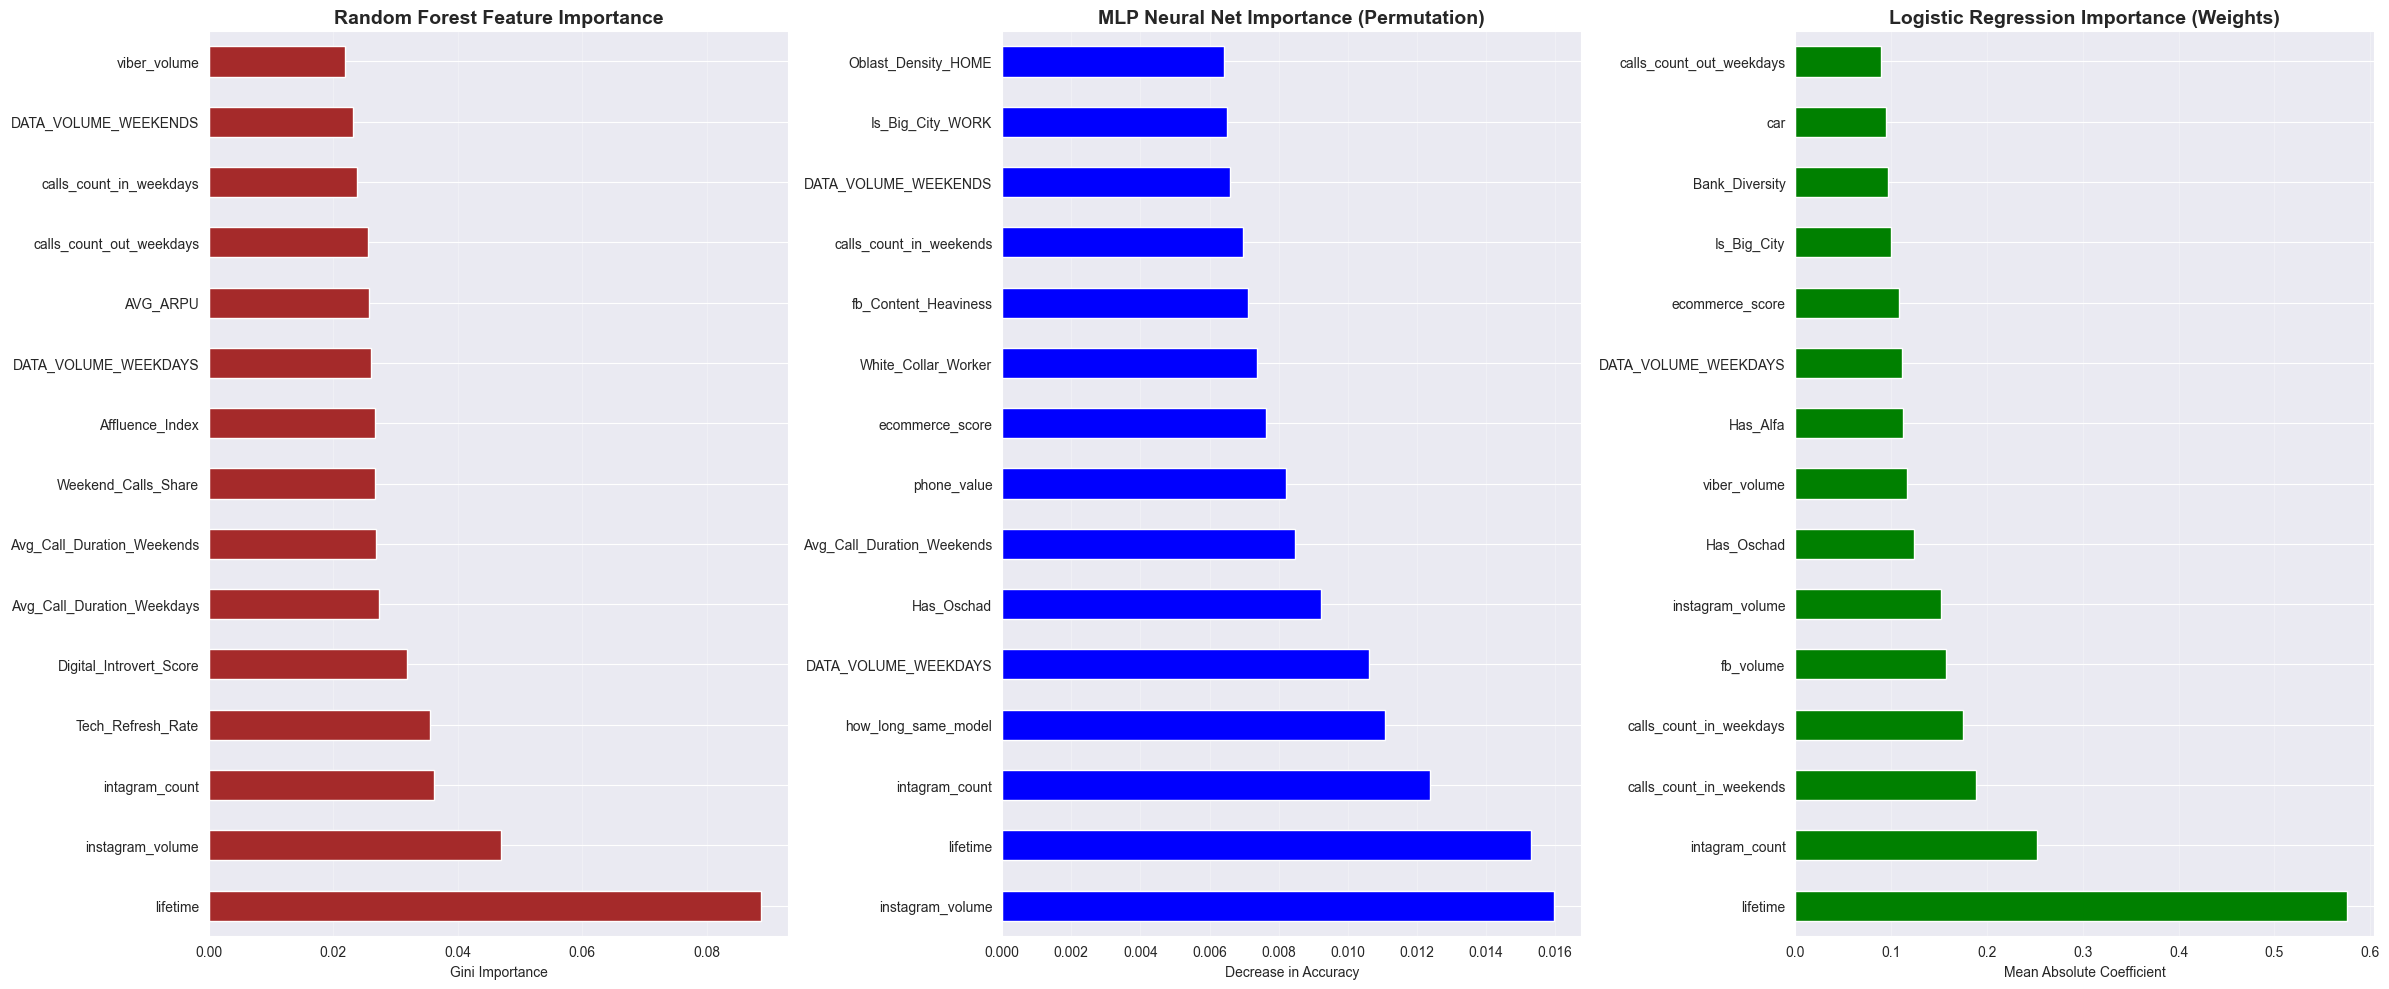

In [121]:
from sklearn.inspection import permutation_importance

# FOR 3 CLASSES
y_target = df['target'].map(group_map)
X_train_4, X_test_4, y_train_4, y_test_4 = train_test_split(
    X, y_target, test_size=0.2, random_state=2025, stratify=y_target
)

scaler = StandardScaler()
X_train_scaled_4 = scaler.fit_transform(X_train_4)
X_test_scaled_4 = scaler.transform(X_test_4)

best_rf = history['3_classes']['models']['RF']
best_mlp = history['3_classes']['models']['MLP']
best_lr = history['3_classes']['models']['LogReg']

fig, ax = plt.subplots(1, 3, figsize=(24, 10))

# RF
feat_imp_rf = pd.Series(best_rf.feature_importances_, index=X.columns)
feat_imp_rf.nlargest(15).plot(kind='barh', ax=ax[0], color='brown')
ax[0].set_title('Random Forest Feature Importance', fontsize=14, fontweight='bold')
ax[0].set_xlabel('Gini Importance')
ax[0].grid(axis='x', alpha=0.3)


# MLP (Permutation Importance) ---
perm_importance = permutation_importance(best_mlp, X_test_scaled_4, y_test_4, n_repeats=10, random_state=2025, n_jobs=-1)

feat_imp_mlp = pd.Series(perm_importance.importances_mean, index=X.columns)
feat_imp_mlp.nlargest(15).plot(kind='barh', ax=ax[1], color='blue')
ax[1].set_title('MLP Neural Net Importance (Permutation)', fontsize=14, fontweight='bold')
ax[1].set_xlabel('Decrease in Accuracy')
ax[1].set_ylabel('')
ax[1].grid(axis='x', alpha=0.3)


# Logistic Regression
lr_coeffs = np.mean(np.abs(best_lr.coef_), axis=0)
feat_imp_lr = pd.Series(lr_coeffs, index=X.columns)
feat_imp_lr.nlargest(15).plot(kind='barh', ax=ax[2], color='green')
ax[2].set_title('Logistic Regression Importance (Weights)', fontsize=14, fontweight='bold')
ax[2].set_xlabel('Mean Absolute Coefficient')
ax[2].set_ylabel('')
ax[2].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()